In [1]:
import pandas as pd

In [2]:
flat_windowd_df = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/fold0_selected_genomic_windows_centered.tsv", sep="\t")

In [3]:
chromhmm_df = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/mESC_chromatin_states.bed", sep="\t", header=None)

In [4]:
chromhmm_df.columns = ["chrom", "start", "end", "state"]

In [5]:
state_map = {
    "E1": "active",
    "E2": "neutral",
    "E3": "neutral",
    "E4": "repressive"
}
chromhmm_df["state_label"] = chromhmm_df["state"].map(state_map)

In [6]:
import bioframe as bf

In [7]:
flat_windowd_df = flat_windowd_df.rename(columns={"start": "og_start", "end": "og_end"})

In [8]:
cropping = 64
bin_size = 2048

In [9]:
flat_windowd_df["start"] = flat_windowd_df["centered_start"] + (flat_windowd_df["centered_flat_start"] + cropping) * bin_size

In [10]:
flat_windowd_df["end"] = flat_windowd_df["centered_start"] + (flat_windowd_df["centered_flat_end"] + cropping) * bin_size

In [11]:
overlap_df = bf.overlap(
    flat_windowd_df,
    chromhmm_df,
    return_index=True,
    suffixes=("_query", "_chromhmm")
)

In [12]:
overlap_df

,index_query,chrom_query,og_start_query,og_end_query,fold_query,PearsonR_query,flat_start_query,flat_end_query,centered_start_query,centered_end_query,centered_flat_start_query,centered_flat_end_query,start_query,end_query,index_chromhmm,chrom_chromhmm,start_chromhmm,end_chromhmm,state_chromhmm,state_label_chromhmm
0,0,chr7,116959232,118269952,fold1,0.721373,170.0,279.0,116893696,118204416,202,310,117438464,117659648,234818,chr7,117430400,117472200,E3,neutral
1,0,chr7,116959232,118269952,fold1,0.721373,170.0,279.0,116893696,118204416,202,310,117438464,117659648,234819,chr7,117472200,117473200,E1,active
2,0,chr7,116959232,118269952,fold1,0.721373,170.0,279.0,116893696,118204416,202,310,117438464,117659648,234820,chr7,117473200,117522000,E3,neutral
3,0,chr7,116959232,118269952,fold1,0.721373,170.0,279.0,116893696,118204416,202,310,117438464,117659648,234821,chr7,117522000,117523000,E1,active
4,0,chr7,116959232,118269952,fold1,0.721373,170.0,279.0,116893696,118204416,202,310,117438464,117659648,234822,chr7,117523000,118042600,E3,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356,76,chr1,72241152,73551872,fold1,0.779139,301.0,443.0,72478720,73789440,185,327,72988672,73279488,120567,chr1,73250000,73250200,E4,repressive
1357,76,chr1,72241152,73551872,fold1,0.779139,301.0,443.0,72478720,73789440,185,327,72988672,73279488,120568,chr1,73250200,73250800,E2,neutral
1358,76,chr1,72241152,73551872,fold1,0.779139,301.0,443.0,72478720,73789440,185,327,72988672,73279488,120569,chr1,73250800,73251000,E4,repressive
1359,76,chr1,72241152,73551872,fold1,0.779139,301.0,443.0,72478720,73789440,185,327,72988672,73279488,120570,chr1,73251000,73362800,E3,neutral


In [13]:
result = overlap_df[[
    "chrom_query", "start_query", "end_query", "state_chromhmm", "state_label_chromhmm", "centered_start_query", "centered_end_query"
]]

In [21]:
grouped = result.groupby(["chrom_query", "start_query", "end_query", "centered_start_query", "centered_end_query", "state_label_chromhmm"]).size().reset_index(name="count")

In [22]:
pivoted = grouped.pivot_table(
    index=["chrom_query", "start_query", "end_query", "centered_start_query", "centered_end_query"],
    columns="state_label_chromhmm",
    values="count",
    fill_value=0
).reset_index()

In [23]:
pivoted.columns.name = None
pivoted = pivoted.rename(columns={
    "active": "active_count",
    "neutral": "neutral_count",
    "repressive": "repressive_count"
})

In [24]:
pivoted["total"] = pivoted[["active_count", "neutral_count", "repressive_count"]].sum(axis=1)

In [25]:
for label in ["active", "neutral", "repressive"]:
    pivoted[f"{label}_fraction"] = pivoted[f"{label}_count"] / pivoted["total"]

In [26]:
pivoted

,chrom_query,start_query,end_query,centered_start_query,centered_end_query,active_count,neutral_count,repressive_count,total,active_fraction,neutral_fraction,repressive_fraction
0,chr1,51017728,51267584,50487296,51798016,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
1,chr1,55470080,55678976,54919168,56229888,0.0,3.0,2.0,5.0,0.000000,0.600000,0.400000
2,chr1,62328832,62640128,61829120,63139840,1.0,6.0,3.0,10.0,0.100000,0.600000,0.300000
3,chr1,66222080,66426880,65669120,66979840,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
4,chr1,68665344,69062656,68208640,69519360,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
72,chr7,136146944,136372224,135604224,136914944,4.0,27.0,22.0,53.0,0.075472,0.509434,0.415094
73,chr7,136548352,136769536,136003584,137314304,3.0,39.0,35.0,77.0,0.038961,0.506494,0.454545
74,chr7,140296192,140627968,139806720,141117440,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
75,chr8,10625024,10919936,10117120,11427840,6.0,57.0,49.0,112.0,0.053571,0.508929,0.437500


In [28]:
pivoted.to_csv("/scratch1/smaruj/genomic_insertion_loci/fold1_chromatin_state_fractions.tsv", sep="\t", index=False)

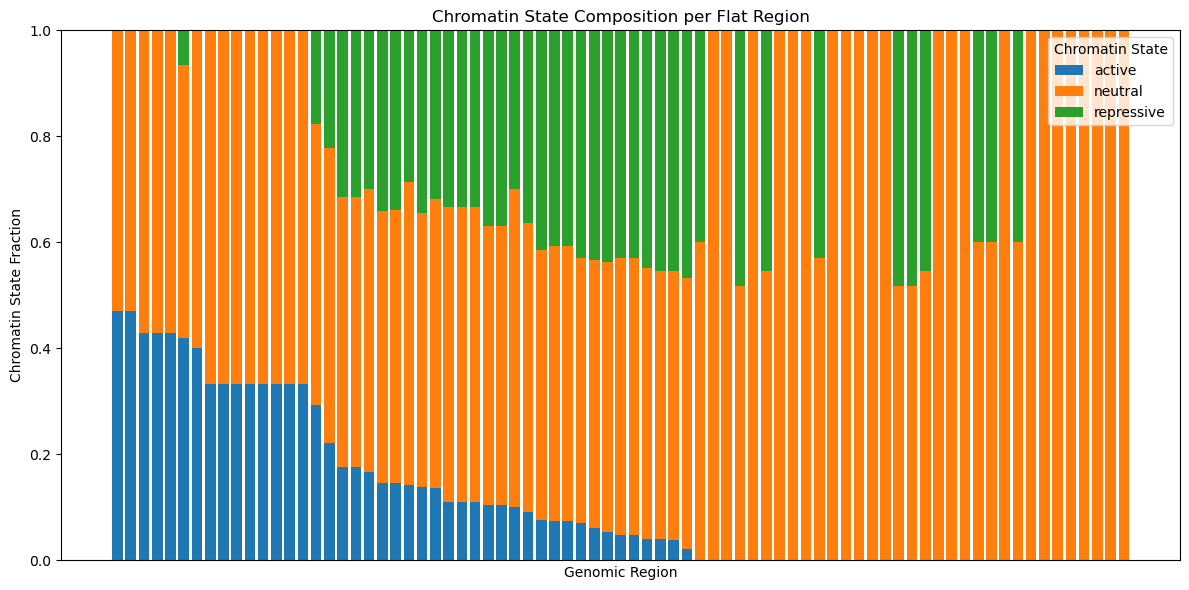

In [20]:
import matplotlib.pyplot as plt

# Sort by one of the fractions (optional)
pivoted_sorted = pivoted.sort_values("active_fraction", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bottoms = [0] * len(pivoted_sorted)

for label, color in zip(["active", "neutral", "repressive"], [None, None, None]):
    ax.bar(
        x=range(len(pivoted_sorted)),
        height=pivoted_sorted[f"{label}_fraction"],
        bottom=bottoms,
        label=label
    )
    bottoms = [sum(x) for x in zip(bottoms, pivoted_sorted[f"{label}_fraction"])]

ax.set_xlabel("Genomic Region")
ax.set_ylabel("Chromatin State Fraction")
ax.set_title("Chromatin State Composition per Flat Region")
ax.legend(title="Chromatin State")
ax.set_xticks([])  # Optional: hide x labels if not meaningful
plt.tight_layout()
plt.show()